## Potts algorithm comparison code

In this notebook the accuracy and complexity of the different inference methods are investigated for the Potts model with $q = 3$ states over 4 parameter regimes, where $\mathcal{N}(\mu, \sigma)$ denotes a normal distribution with mean $\mu$ and standard deviation $\sigma$. As the TAP and Bethe approximations are only implemented for the Ising model, these are left out. Unlike the Ising model, a constant shift of all fields or couplings does nothing for the Potts model, as it does not favour any state and is removed by the gauge. The regimes are therefore built with a Potts coupling $c\,(\delta_{ab} - 1/q)$, which makes a pair prefer equal states for $c > 0$ and different states for $c < 0$.

The first is the "normal" regime, with $h_i(a) \sim \mathcal{N}(0, 0.3)$ and $J_{ij}(a, b) \sim \mathcal{N}(0, 0.3)$. The second is a strongly coupled regime, where every pair gets an extra Potts coupling with $c = 0.4$ on top of the normal regime. The third has a limited number of strong couplings, with a weak background of $J_{ij}(a, b) \sim \mathcal{N}(0, 0.05)$ and four strong pairs with $c$ between $-1.2$ and $1.0$. The last has biased fields, where every site gets an extra field of $1.0$ towards state 0 on top of the normal regime. In the last part of the notebook I will show the time complexity of the different methods for varying numbers of sites and states.


In [25]:
import numpy as np
import time
import matplotlib.pyplot as plt

BACKEND = "numba"
ACE_THRESHOLD, ACE_MAX_SIZE = 1e-4, 10
X_INF = 1e6

# Model
from spininfer.models.potts import PottsModel

# Fitters
from spininfer.fitters.mean_field_fitter import NaiveMeanFieldFitter, IndependentPairFitter, SessakMonassonFitter
from spininfer.fitters.lbfgs_fitter import LbfgsFitter
from spininfer.fitters.ACE_fitter import ACEFitter

# Objectives
from spininfer.objectives.PLE_potts import PlePottsObjective
from spininfer.objectives.moment_matching import MomentMatchingObjective
from spininfer.stats.exact_estimator import ExactEstimator

# Data
from spininfer.data.generate import generate_data
from spininfer.data.dataset import Dataset
from spininfer.stats.moments import Moments

SAMPLE_SIZES = [100, 500, 1_000, 5_000, 10_000, 50_000, 100_000]
N_SWEEPS = 1000 


def get_datasets(model, h, J, seed, sample_sizes=SAMPLE_SIZES, n_sweeps=N_SWEEPS):
    truth = generate_data(model=model, n_samples=max(sample_sizes), iterations=n_sweeps * model.n_sites,
                          seed=seed, h=h, J=J)
    datasets = {m: Dataset(samples=truth.samples[:m], model=model) for m in sample_sizes}

    mean_s, mean_ss = model.exact_statistics(h, J)
    datasets[np.inf] = Dataset(model=model, moments=Moments(mean_s=mean_s, mean_ss=mean_ss))
    return datasets


def _zeros(model):
    xp = model.array_backend.xp
    return xp.zeros((model.n_sites, model.n_states)), xp.zeros((model.n_sites, model.n_sites, model.n_states, model.n_states))


def _fit(fitter, *init):
    result = fitter.fit(*init)
    return result.h, result.J

# Make a dict of all the methods
METHODS = {
    "nMF": lambda m, d: _fit(NaiveMeanFieldFitter(model=m, dataset=d)),
    "IPA": lambda m, d: _fit(IndependentPairFitter(model=m, dataset=d)),
    "SM": lambda m, d: _fit(SessakMonassonFitter(model=m, dataset=d)),
    "ACE": lambda m, d: _fit(ACEFitter(model=m, dataset=d, threshold=ACE_THRESHOLD, regularizer=None, max_size=ACE_MAX_SIZE)),
    "PLE": lambda m, d: _fit(LbfgsFitter(model=m, dataset=d, objective=PlePottsObjective()), *_zeros(m)),
    "exact ML": lambda m, d: _fit(LbfgsFitter(model=m, dataset=d, objective=MomentMatchingObjective(ExactEstimator())), *_zeros(m)),
}
NEEDS_SAMPLES = {"PLE"}


def run_experiment(model, h, J, datasets, methods=METHODS):
    xp = model.array_backend.xp
    results = []
    for name, method in methods.items():
        for M, dataset in datasets.items():
            if M == np.inf and name in NEEDS_SAMPLES:
                continue
            start = time.perf_counter()
            h_fit, J_fit = method(model, dataset)
            elapsed = time.perf_counter() - start
            results.append({
                "method": name,
                "M": M,
                "time": elapsed,
                "h_err": xp.abs(h_fit - h).mean(),
                "J_err": xp.linalg.norm(J_fit - J) / np.linalg.norm(J),
            })
    return results


def plot_results(results, title):
    panels = [("J_err", "relative J error"), ("h_err", "mean |h error|"), ("time", "fit time [s]")]
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    for name in dict.fromkeys(r["method"] for r in results):
        rows = [r for r in results if r["method"] == name]
        x = [X_INF if r["M"] == np.inf else r["M"] for r in rows]
        for ax, (key, _) in zip(axes, panels):
            ax.plot(x, [r[key] for r in rows], "o-", label=name)
    for ax, (_, label) in zip(axes, panels):
        ax.set(xscale="log", yscale="log", xlabel="number of samples M", ylabel=label)
        ax.set_xticks([1e2, 1e3, 1e4, 1e5, X_INF], ["$10^2$", "$10^3$", "$10^4$", "$10^5$", r"$\infty$"])
        ax.xaxis.set_minor_locator(plt.NullLocator())
    axes[0].legend(fontsize=8)
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()


def warm_up(methods=METHODS):
    model = PottsModel(n_sites=4, n_states=3, backend=BACKEND)
    h, J = model.random_params(seed=0)
    for M, dataset in get_datasets(model, h, J, seed=0, sample_sizes=[200], n_sweeps=10).items():
        for name, method in methods.items():
            if not (M == np.inf and name in NEEDS_SAMPLES):
                method(model, dataset)


warm_up()

### Standard regime

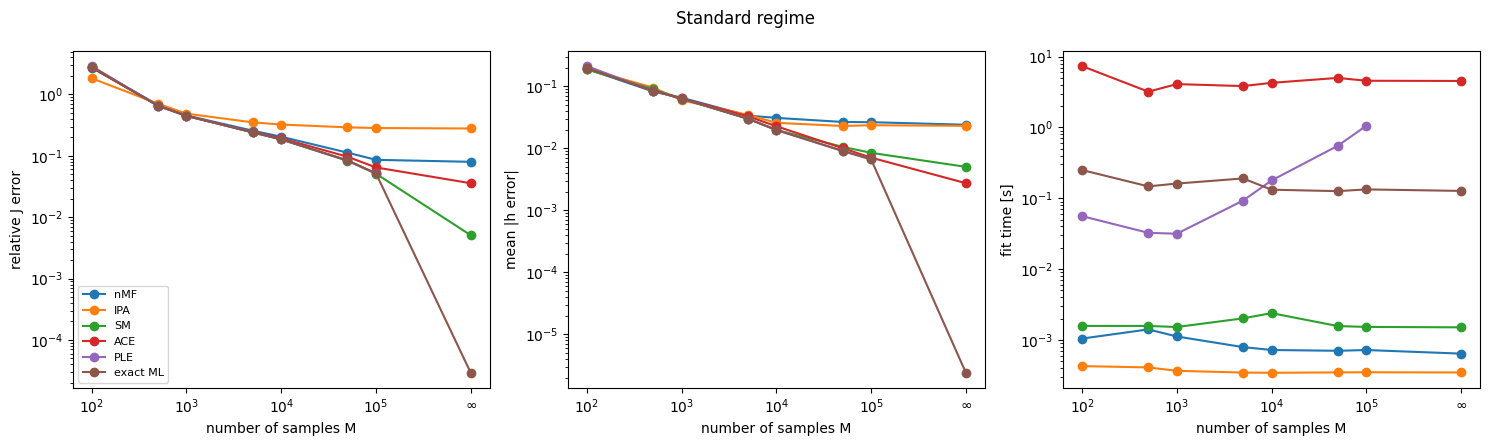

In [26]:
model = PottsModel(n_sites=8, n_states=3, backend=BACKEND)
h, J = model.random_params(loc_h=0.0, scale_h=0.3, loc_J=0.0, scale_J=0.3, seed=0)

datasets = get_datasets(model, h, J, seed=0)

results_standard = run_experiment(model, h, J, datasets)
plot_results(results_standard, "Standard regime")


In the standard regime the Sessak Monasson approximation gets very close to the exact result, with a relative error of around $5 \cdot 10^{-3}$ at infinite samples, which is a lot better than in the Ising case. This is because the same parameter scale gives weaker effective couplings for the Potts model as the gauge removes part of every coupling block, and a one-hot state indicator fluctuates a lot less than an Ising spin, so the correlations stay small, which is exactly where the Sessak Monasson method works well. The naive mean field and IPA methods level off at around 0.08 and 0.27. Finally, the PLE and exact MLE again have near identical performance.

### Strongly coupled regime

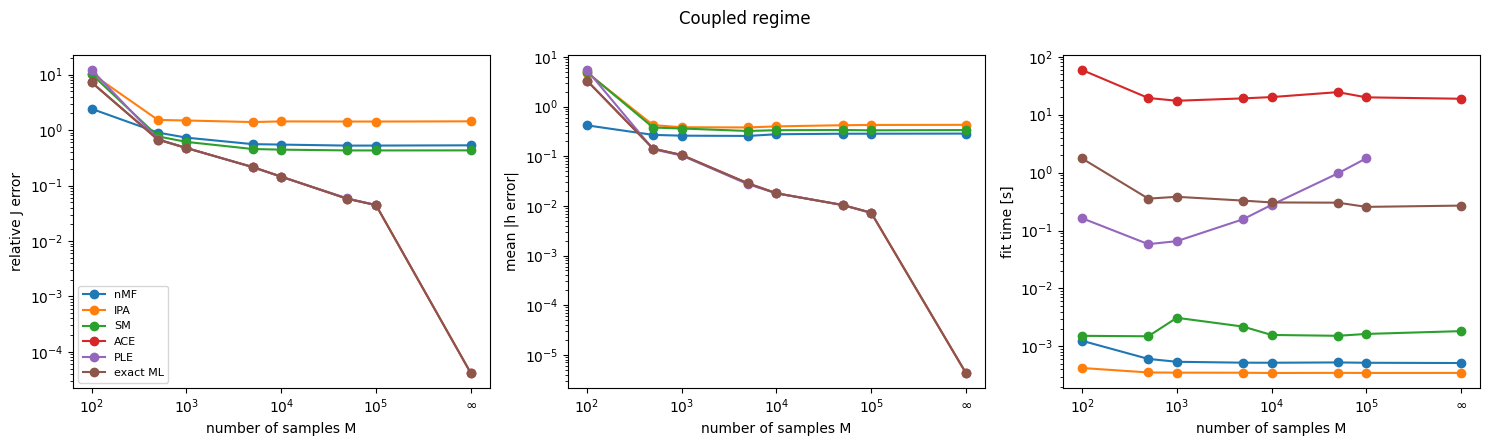

In [27]:
model = PottsModel(n_sites=8, n_states=3, backend=BACKEND)
h, J = model.random_params(loc_h=0.0, scale_h=0.3, loc_J=0.0, scale_J=0.3, seed=0)

xp = model.array_backend.xp
q = model.n_states
off_diagonal = 1.0 - xp.eye(model.n_sites)[:, :, None, None]
J = xp.array(J) + 0.4 * off_diagonal * (xp.eye(q) - 1.0 / q)
h, J = model.apply_gauge(h, J)


datasets = get_datasets(model, h, J, seed=0)

results_strong_coupling = run_experiment(model, h, J, datasets)
plot_results(results_strong_coupling, "Coupled regime")

In the strongly coupled regime all of the mean field methods break down, with relative errors between 0.45 and 1.5 that do not improve with more data. Only the MLE and PLE keep improving with the number of samples. ACE is hidden behind the MLE here. As everything is strongly correlated, almost all clusters are kept up to the full system, which is the same as the exact MLE but around 70 times slower. At 100 samples the naive mean field method has the lowest error, as it cannot overfit the noise in the data in the way the unregularized MLE and PLE do.

### Limited strong coupling regime

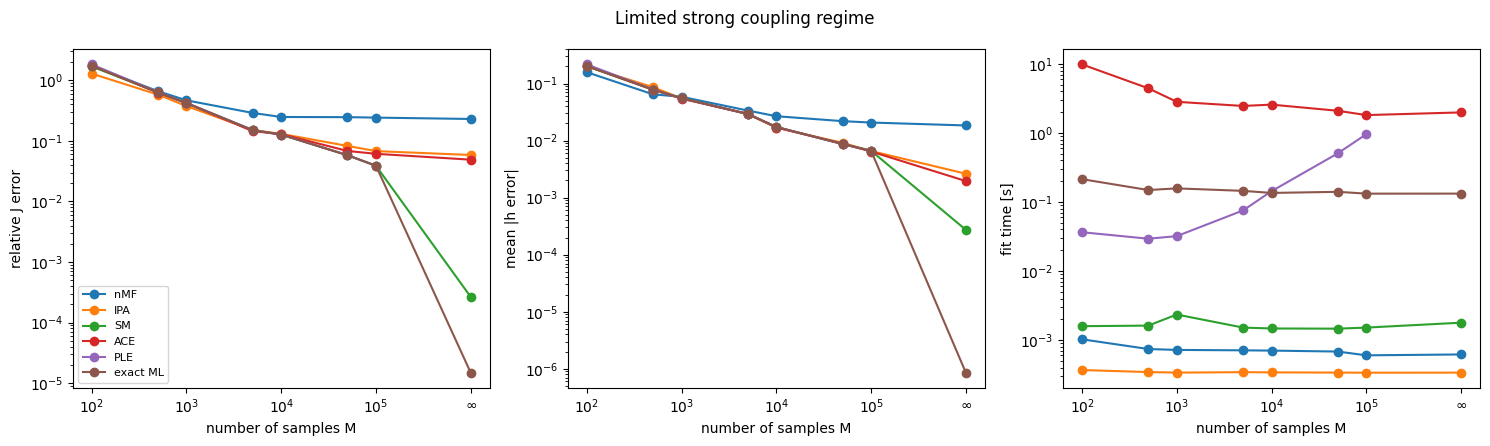

In [28]:
model = PottsModel(n_sites=8, n_states=3, backend=BACKEND)
h, J = model.random_params(loc_h=0.0, scale_h=0.3, loc_J=0.0, scale_J=0.05, seed=0)

xp = model.array_backend.xp
q = model.n_states
potts_block = np.eye(q) - 1.0 / q
J = np.array(J)
for i, j, c in [(0, 1, 1.0), (4, 5, 1.0), (3, 7, 0.8), (2, 6, -1.2)]:
    J[i, j] = c * potts_block
    J[j, i] = J[i, j].T
J = xp.asarray(J)

datasets = get_datasets(model, h, J, seed=0)

results_sparse = run_experiment(model, h, J, datasets)
plot_results(results_sparse, "Limited strong coupling regime")

In the sparse regime the Sessak Monasson approximation is almost exact, with an error of around $3 \cdot 10^{-4}$ at infinite samples. The strong pairs do not share any sites and the background is weak, so the system is almost a set of independent pairs, for which the Sessak Monasson approximation is exact. The IPA and ACE level off at around 0.05, as the IPA misses the weak background couplings since it does not have the background correction IPA has.ACE does not fit the clusters that are only connected through the weak background and thus also performs poorly. The naive mean field method cannot handle the strong couplings and levels off at around 0.23. The MLE and PLE methods remain identical in performance.


### Biased magnetization regime

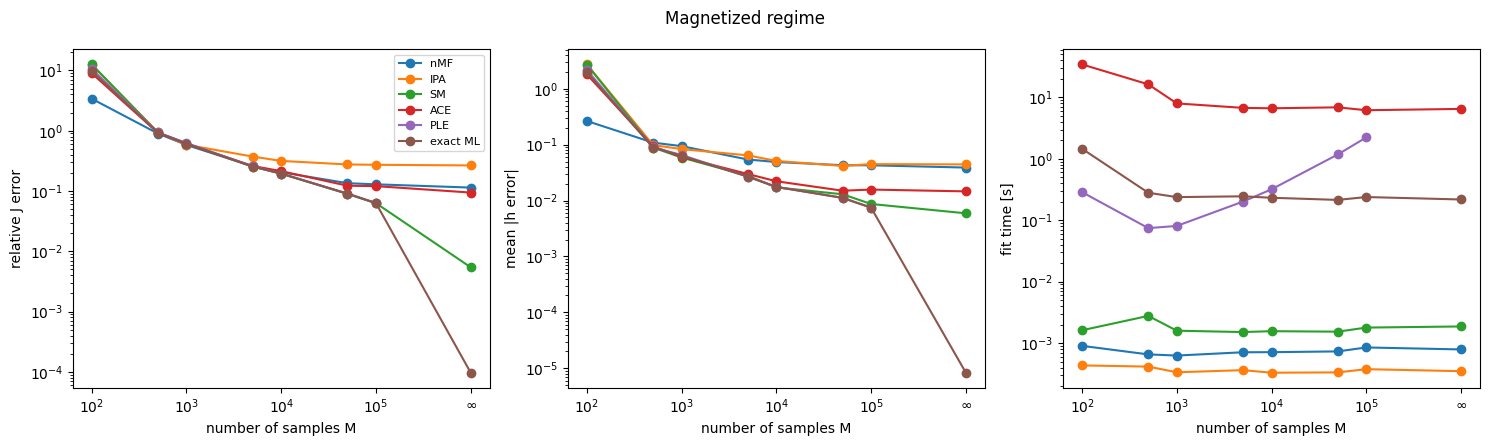

In [29]:
model = PottsModel(n_sites=8, n_states=3, backend=BACKEND)
h, J = model.random_params(loc_h=0.0, scale_h=0.3, loc_J=0.0, scale_J=0.3, seed=0)
h = np.array(h)
h[:, 0] += 1.0
h, J = model.apply_gauge(h, J)

datasets = get_datasets(model, h, J, seed=0)

results_magnetized = run_experiment(model, h, J, datasets)
plot_results(results_magnetized, "Magnetized regime")

In the magnetized regime the results are very similar to the standard regime, with the Sessak Monasson approximation again close to the exact result. This shows that biased fields alone do not break the mean field methods, as they do not make the couplings between the sites any stronger. This would only change when sites become close to frozen, so that some states are almost never observed. With a bias of $1.0$ the most likely state has a probability of around 0.8, so every state is still observed regularly. In practice this frozen state is a real problem and should be approached carefully through regularization.

In all regimes the errors of the MLE, PLE and ACE are large at 100 samples. This is because none of these methods are regularized here, and 100 samples is too few to pin down all the parameters. Adding L2 regularization (see the regularization demo) prevents this.


### Sites time complexity

N = 3 done
N = 4 done
N = 5 done
N = 6 done
N = 7 done
N = 8 done
N = 9 done
N = 10 done
N = 11 done


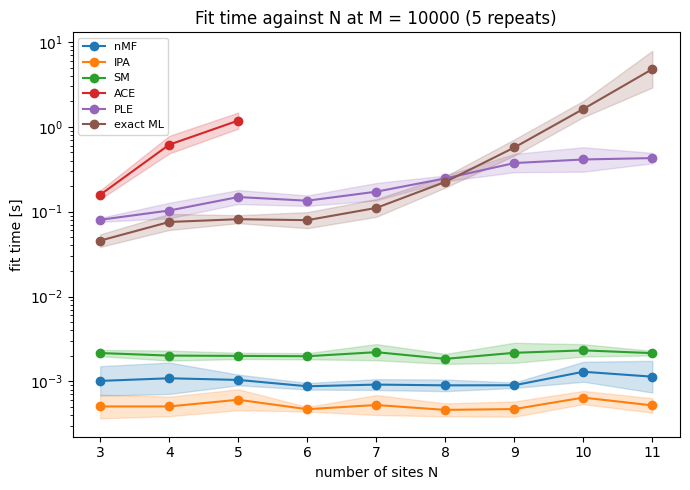

In [30]:
N_VALUES = [3, 4, 5, 6, 7, 8, 9, 10, 11]
M_FIXED = 10_000
N_REPEATS = 5
MAX_SITES = {"ACE": 5}  # largest N to run each slow method on

results_sites = []
for n in N_VALUES:
    model = PottsModel(n_sites=n, n_states=3, backend=BACKEND)
    scale_J = 0.3 * np.sqrt(10 / n)
    methods = {name: f for name, f in METHODS.items() if n <= MAX_SITES.get(name, np.inf)}
    for seed in range(N_REPEATS):
        h, J = model.random_params(loc_h=0.0, scale_h=0.3, loc_J=0.0, scale_J=scale_J, seed=seed)
        datasets = get_datasets(model, h, J, seed=seed, sample_sizes=[M_FIXED])
        datasets.pop(np.inf)
        for row in run_experiment(model, h, J, datasets, methods=methods):
            results_sites.append({**row, "N": n, "seed": seed})
    print(f"N = {n} done")


def plot_time_vs_sites(results, M, title):
    fig, ax = plt.subplots(figsize=(7, 5))
    for name in dict.fromkeys(r["method"] for r in results):
        rows = [r for r in results if r["method"] == name and r["M"] == M]
        if not rows:
            continue
        ns = sorted({r["N"] for r in rows})
        logs = [np.log10([r["time"] for r in rows if r["N"] == n]) for n in ns]
        mean = np.array([l.mean() for l in logs])
        std = np.array([l.std() for l in logs])
        line, = ax.plot(ns, 10**mean, "o-", label=name)
        ax.fill_between(ns, 10**(mean - std), 10**(mean + std), color=line.get_color(), alpha=0.2)
    ax.set(yscale="log", xlabel="number of sites N", ylabel="fit time [s]", title=title)
    ax.legend(fontsize=8)
    fig.tight_layout()
    plt.show()


plot_time_vs_sites(results_sites, M_FIXED, f"Fit time against N at M = {M_FIXED} ({N_REPEATS} repeats)")

In this plot it is clear that the exact MLE scales exponentially with the number of sites, as it has to enumerate all $q^N = 3^N$ states. Below $N \approx 8$ the exact MLE is faster than the PLE, but above this point the PLE quickly becomes the faster option. This crossover lies at fewer sites than for the Ising model ($N \approx 11$), as $3^N$ grows faster than $2^N$. The mean field methods stay at around a millisecond, as their time is dominated by overhead at these system sizes, while ACE, in this regime, grows steeply and was therefore only run up to 5 sites.

### States time complexity

N = 2 done
N = 3 done
N = 4 done
N = 5 done
N = 6 done
N = 7 done
N = 8 done
N = 9 done
N = 10 done


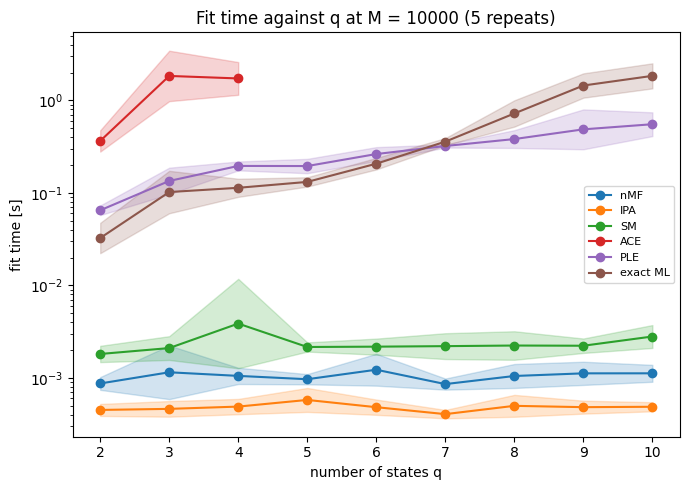

In [31]:
N_STATES = [2, 3, 4, 5, 6, 7, 8, 9, 10]
M_FIXED = 10_000
N_REPEATS = 5
MAX_STATES = {"ACE": 4}

results_states = []
for n in N_STATES:
    model = PottsModel(n_sites=5, n_states=n, backend=BACKEND)
    scale_J = 0.3
    methods = {name: f for name, f in METHODS.items() if n <= MAX_STATES.get(name, np.inf)}
    for seed in range(N_REPEATS):
        h, J = model.random_params(loc_h=0.0, scale_h=0.3, loc_J=0.0, scale_J=scale_J, seed=seed)
        datasets = get_datasets(model, h, J, seed=seed, sample_sizes=[M_FIXED])
        datasets.pop(np.inf)
        for row in run_experiment(model, h, J, datasets, methods=methods):
            results_states.append({**row, "N": n, "seed": seed})
    print(f"N = {n} done")


def plot_time_vs_states(results, M, title):
    fig, ax = plt.subplots(figsize=(7, 5))
    for name in dict.fromkeys(r["method"] for r in results):
        rows = [r for r in results if r["method"] == name and r["M"] == M]
        if not rows:
            continue
        ns = sorted({r["N"] for r in rows})
        logs = [np.log10([r["time"] for r in rows if r["N"] == n]) for n in ns]
        mean = np.array([l.mean() for l in logs])
        std = np.array([l.std() for l in logs])
        line, = ax.plot(ns, 10**mean, "o-", label=name)
        ax.fill_between(ns, 10**(mean - std), 10**(mean + std), color=line.get_color(), alpha=0.2)
    ax.set(yscale="log", xlabel="number of states q", ylabel="fit time [s]", title=title)
    ax.legend(fontsize=8)
    fig.tight_layout()
    plt.show()


plot_time_vs_states(results_states, M_FIXED, f"Fit time against q at M = {M_FIXED} ({N_REPEATS} repeats)")

For a fixed number of sites the exact MLE scales a lot more mildly with the number of states, as the $q^N$ states then only grow as a polynomial in $q$, here $q^5$. From 2 to 10 states the fit time grows by a factor of around 100, and the PLE and exact MLE cross at around $q = 7$. This means that the number of sites is what makes the exact MLE expensive. For proteins, with $q = 21$ and hundreds of sites, enumerating all states is not possible at all, which is why the PLE is the standard method there.